# AI-Enhanced Intrusion Detection System
### Exploratory Data Analysis, Model Training & Evaluation (NSL-KDD Dataset)

This notebook documents the data exploration, preprocessing, model training and
evaluation steps for the intrusion detection milestones (Milestones 2-9 of the
project plan). It complements the standalone scripts in `src/` which can be
run as a pipeline (`python src/preprocessing.py`, `python src/train.py`,
`python src/evaluate.py`) — this notebook reproduces the same steps inline
so the work can be screenshotted/discussed for the project report.

In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from constants import COLUMN_NAMES, ATTACK_CATEGORY_MAP, ATTACK_CATEGORIES
from preprocessing import load_raw, add_attack_category, build_datasets

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

## 1. Load Raw Data (Milestone 2: Data Collection & Preparation)

In [2]:
train_path = '../data/KDDTrain+.txt'
test_path = '../data/KDDTest+.txt'

train_raw = load_raw(train_path)
test_raw = load_raw(test_path)

print('Train shape:', train_raw.shape)
print('Test shape:', test_raw.shape)
train_raw.head()

Train shape: (125973, 43)
Test shape: (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


## 2. Label Distribution & Attack Categories

In [3]:
train_cat = add_attack_category(train_raw)

print('Raw attack labels in train set:', train_cat['label'].nunique())
train_cat['attack_category'].value_counts()

Raw attack labels in train set: 23


attack_category
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

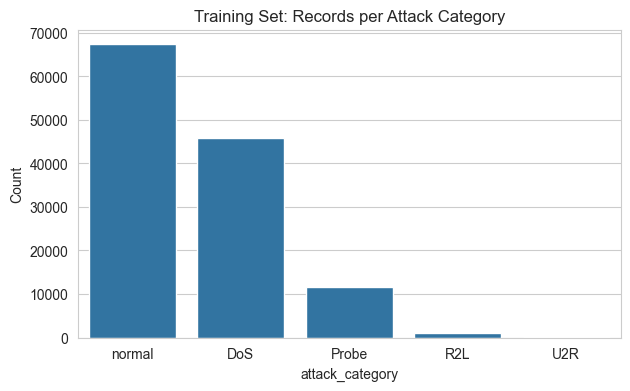

In [4]:
plt.figure(figsize=(7,4))
sns.countplot(data=train_cat, x='attack_category',
              order=ATTACK_CATEGORIES)
plt.title('Training Set: Records per Attack Category')
plt.ylabel('Count')
plt.show()

**Observation:** the dataset is heavily imbalanced — `normal` and `DoS`
traffic dominate, while `R2L` and especially `U2R` attacks are rare. This
imbalance is expected to make those classes harder to detect, which we
verify later in the evaluation step.

## 3. Feature Engineering & Preprocessing (Milestone 3)

Categorical columns (`protocol_type`, `service`, `flag`) are label-encoded and all 41 numeric features are standardized (zero mean, unit variance) using `StandardScaler`. The 39 raw attack labels are collapsed into 5 categories: `normal`, `DoS`, `Probe`, `R2L`, `U2R`.

In [5]:
X_train, X_test, y_train, y_test, encoders, scaler, feature_cols = \
    build_datasets(train_path, test_path)

print('Processed train shape:', X_train.shape)
print('Processed test shape:', X_test.shape)
X_train.head()

Processed train shape: (125973, 41)
Processed test shape: (22544, 41)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,-0.110249,-0.124706,-0.686785,0.751111,-0.007679,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,-0.027023,-0.809262,-0.011664,-0.036652,-0.024437,-0.012385,-0.02618,-0.01861,-0.041221,0.0,-0.002817,-0.097531,-0.717045,-0.354343,-0.637209,-0.631929,-0.374362,-0.374432,0.771283,-0.349683,-0.374560,-0.324063,-0.818890,-0.782367,-0.280282,0.069972,-0.289103,-0.639532,-0.624871,-0.224532,-0.376387
1,-0.110249,2.219312,0.781428,0.751111,-0.007737,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,-0.027023,-0.809262,-0.011664,-0.036652,-0.024437,-0.012385,-0.02618,-0.01861,-0.041221,0.0,-0.002817,-0.097531,-0.620982,-0.368110,-0.637209,-0.631929,-0.374362,-0.374432,-1.321428,0.482201,-0.374560,0.734343,-1.035688,-1.161030,2.736852,2.367737,-0.289103,-0.639532,-0.624871,-0.387635,-0.376387
2,-0.110249,-0.124706,1.087305,-0.736235,-0.007762,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,-0.027023,-0.809262,-0.011664,-0.036652,-0.024437,-0.012385,-0.02618,-0.01861,-0.041221,0.0,-0.002817,-0.097531,0.339648,-0.299273,1.602664,1.605104,-0.374362,-0.374432,-1.389669,0.038529,-0.374560,0.734343,-0.809857,-0.938287,-0.174417,-0.480197,-0.289103,1.608759,1.618955,-0.387635,-0.376387
3,-0.110249,-0.124706,-0.442083,0.751111,-0.007723,-0.002891,-0.014089,-0.089486,-0.007736,-0.095076,-0.027023,1.235694,-0.011664,-0.036652,-0.024437,-0.012385,-0.02618,-0.01861,-0.041221,0.0,-0.002817,-0.097531,-0.690846,-0.313041,-0.189235,-0.184522,-0.374362,-0.374432,0.771283,-0.349683,-0.374560,-1.533670,1.258754,1.066401,-0.439078,-0.383108,0.066252,-0.572083,-0.602433,-0.387635,-0.345084
4,-0.110249,-0.124706,-0.442083,0.751111,-0.007728,-0.004814,-0.014089,-0.089486,-0.007736,-0.095076,-0.027023,1.235694,-0.011664,-0.036652,-0.024437,-0.012385,-0.02618,-0.01861,-0.041221,0.0,-0.002817,-0.097531,-0.472521,0.058678,-0.637209,-0.631929,-0.374362,-0.374432,0.771283,-0.349683,-0.028179,0.734343,1.258754,1.066401,-0.439078,-0.480197,-0.289103,-0.639532,-0.624871,-0.387635,-0.376387


## 4. Model Training & Comparison (Milestone 4)

Three classic ML algorithms are trained and compared using 3-fold cross-validated macro F1-score (a fairer metric than accuracy given the class imbalance above).

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import time

models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=20, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=20,
                                             random_state=42, n_jobs=-1),
}

results = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    cv_f1 = cross_val_score(model, X_train, y_train, cv=3, scoring='f1_macro').mean()
    results.append({'model': name, 'train_time_s': round(elapsed,1), 'cv_f1_macro': round(cv_f1,4)})
    print(f'{name}: trained in {elapsed:.1f}s, cv_f1_macro={cv_f1:.4f}')

results_df = pd.DataFrame(results).sort_values('cv_f1_macro', ascending=False)
results_df

Logistic Regression: trained in 21.2s, cv_f1_macro=0.8078
Decision Tree: trained in 3.3s, cv_f1_macro=0.8826


In [ ]:
best_model_name = results_df.iloc[0]['model']
best_model = models[best_model_name]
print('Best model selected:', best_model_name)

## 5. Evaluation on the Held-Out Test Set (Milestone 5 & 9)

The NSL-KDD test set intentionally contains some attack types that never appear in training, plus a different traffic distribution — this is what makes it a meaningful, realistic benchmark rather than a trivial train/test split.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

y_pred = best_model.predict(X_test)

print('Test Accuracy:', round(accuracy_score(y_test, y_pred), 4))
print('Test Macro F1:', round(f1_score(y_test, y_pred, average='macro'), 4))
print()
print(classification_report(y_test, y_pred, labels=ATTACK_CATEGORIES))

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=ATTACK_CATEGORIES)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ATTACK_CATEGORIES, yticklabels=ATTACK_CATEGORIES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

## 6. Conclusions

- Tree-based ensemble methods (Random Forest) outperform linear models on
  this feature set, consistent with published NSL-KDD benchmarks.
- `normal` and `DoS` traffic are detected reliably.
- `R2L` and `U2R` attacks are detected far less reliably — they are rare in
  training, and several specific attack sub-types in the test set never
  appear in the training data at all (a well-known property of NSL-KDD
  designed to test generalization).
- **Future work (Milestone 8/12):** address class imbalance with techniques
  like SMOTE or class-weighting, and explore richer feature engineering or
  deep learning architectures to better catch R2L/U2R patterns.

See `src/train.py`, `src/evaluate.py`, and `src/predict.py` for the
production-style scripts that reproduce and operationalize this pipeline.